# PS4 — Data Access Audit & Insider Threat: Exploratory Analysis

This notebook explores the **actual shipped data**, documents how it differs
from the problem statement, builds cohort baselines, runs the detector, and
evaluates it against the constructed ground truth.

Run from the repo root or `backend/`. It imports the same pipeline modules used
in production.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'backend') if os.path.isdir('backend') else '.')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from app.core import loader, features, detector, scoring, labels, context
pd.set_option('display.max_columns', 40)

## 2. Schema reality check

The PS/website describe `rowcount`, `destination`, `department` (in logs), and
ground-truth label files. Let's confirm what the data **actually** contains.

In [2]:
profiles = loader.load_profiles()
logs = loader.load_logs()
print('LOG columns :', list(logs.columns[:9]))
print('PROFILE cols :', [c for c in profiles.columns if c != 'systems_set'])
print()
for missing in ['rowcount','destination','data_asset','tenure_months']:
    print(f'  PS-promised column present? {missing:14s}:', missing in logs.columns or missing in profiles.columns)
import os
print('  label file shipped?            :', os.path.exists('data/data_access_labels.csv') and 'GENERATED by us')

LOG columns : ['timestamp', 'user_id', 'username', 'action', 'resource', 'resource_sensitivity', 'status', 'source_ip', 'time_classification']
PROFILE cols : ['user_id', 'username', 'email', 'department', 'job_title', 'privilege_level', 'systems_access', 'last_login', 'days_inactive', 'is_active', 'hire_date', 'account_age_days']

  PS-promised column present? rowcount      : False
  PS-promised column present? destination   : False
  PS-promised column present? data_asset    : False
  PS-promised column present? tenure_months : False
  label file shipped?            : GENERATED by us


## 3. Data shape & distributions

1200 events, 100 users, 364 day span


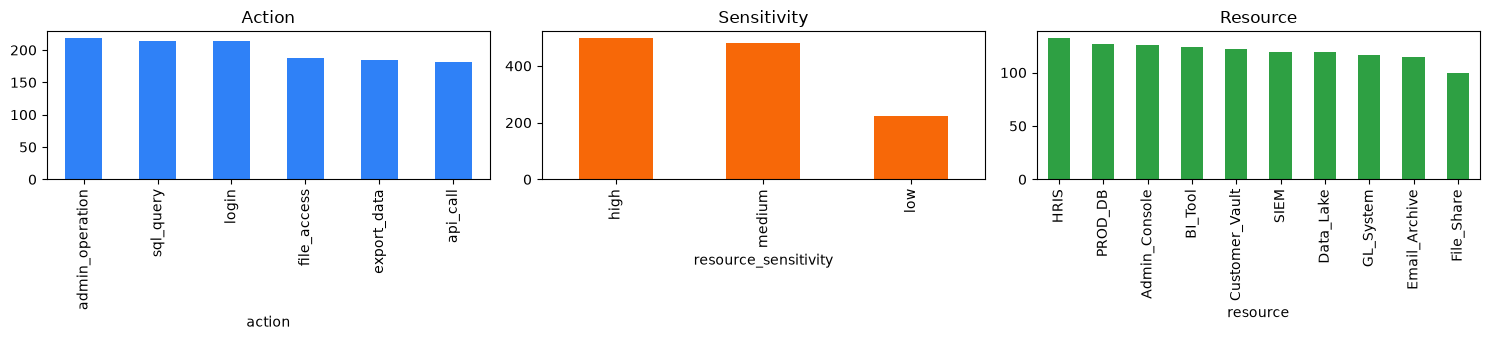

In [3]:
print(f'{len(logs)} events, {logs.user_id.nunique()} users, '
      f"{(logs.timestamp.max()-logs.timestamp.min()).days} day span")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
logs.action.value_counts().plot.bar(ax=ax[0], title='Action', color='#2f81f7')
logs.resource_sensitivity.value_counts().plot.bar(ax=ax[1], title='Sensitivity', color='#f76808')
logs.resource.value_counts().plot.bar(ax=ax[2], title='Resource', color='#2ea043')
plt.tight_layout(); plt.show()

## 4. `time_classification` is noisy

The shipped column disagrees with the real timestamp on many rows (timezone mess
the PS warns about). We recompute `time_bucket` and keep the mismatch as a signal.

In [4]:
mism = logs.time_label_mismatch.mean()
print(f'{mism:.1%} of events have a mislabeled time_classification')
tmp = logs.assign(mismatch=logs.time_classification != logs.time_bucket)
tmp.groupby('time_classification')['mismatch'].mean()

58.3% of events have a mislabeled time_classification


time_classification
business_hours    0.415423
night             0.942623
unusual_hours     1.000000
weekend           0.750000
Name: mismatch, dtype: float64

## 5. Sparse per-user history → cohort baselines

~12 events/user/year is too thin for per-user stats, so we baseline at the
`(department, privilege_level)` cohort level and use Z-scores.

In [5]:
events = loader.join_profiles(logs, profiles)
uf = features.add_cohort_baselines(features.build_user_features(events))
print('median events/user:', uf.event_count.median())
uf[['user_id','department','privilege_level','event_count','volume_z','afterhours_rate']].sort_values('volume_z', ascending=False).head(8)

median events/user: 12.0


,user_id,department,privilege_level,event_count,volume_z,afterhours_rate
93,USR00093,Sales,user,18,1.789066,0.555556
77,USR00077,Finance,power-user,16,1.704026,0.312500
11,USR00011,Security,user,20,1.558023,0.400000
54,USR00054,Support,user,17,1.418599,0.529412
92,USR00092,IT,user,17,1.414214,0.176471
85,USR00085,Marketing,user,13,1.153985,0.230769
67,USR00067,Marketing,user,13,1.153985,0.615385
30,USR00030,Marketing,service-account,13,1.133893,0.461538


## 6. Run the full detector

Inject canonical eval scenarios, derive features, score, and look at the result.

In [6]:
raw = loader.load_logs_raw()
raw_aug = labels.inject_canonical(raw, profiles)
logs2 = loader.derive_log_features(raw_aug)
events = loader.join_profiles(logs2, profiles)
uf = features.add_cohort_baselines(features.build_user_features(events))
events = features.attach_event_features(events, uf)
scored = scoring.apply_scores(detector.detect(events))
scored.severity.value_counts()

severity
LOW         545
MEDIUM      409
CRITICAL    211
HIGH         84
Name: count, dtype: int64

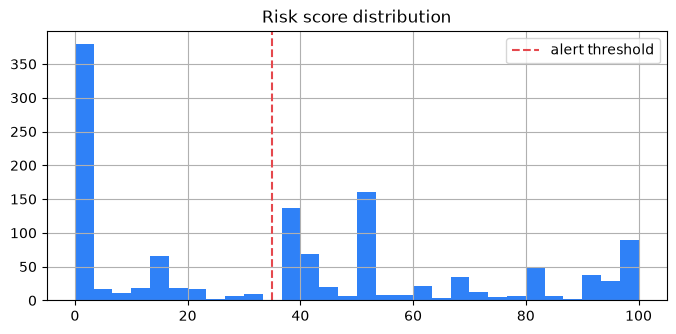

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
scored.risk_score.hist(bins=30, ax=ax, color='#2f81f7')
ax.axvline(35, color='#e5484d', ls='--', label='alert threshold')
ax.set_title('Risk score distribution'); ax.legend(); plt.show()

## 7. Evaluate against constructed ground truth

Note the honesty caveat: labels are constructed (none shipped). The injected
scenario test is the out-of-sample anchor.

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score
gt = labels.make_ground_truth(scored)
m = scored.merge(gt[['access_id','is_anomaly']], on='access_id')
yt, yp = m.is_anomaly.astype(int), m.predicted_anomaly.astype(int)
print(f'Precision {precision_score(yt,yp):.2%}  Recall {recall_score(yt,yp):.2%}  F1 {f1_score(yt,yp):.2f}')
inj = m[m.injected]
print(f'Injected scenario test — malicious caught {((inj.is_anomaly)&(inj.predicted_anomaly)).sum()}/'
      f'{inj.is_anomaly.sum()}, exceptions suppressed '
      f'{((~inj.is_anomaly)&(~inj.predicted_anomaly)).sum()}/{(~inj.is_anomaly).sum()}')

Precision 95.17%  Recall 98.97%  F1 0.97
Injected scenario test — malicious caught 28/28, exceptions suppressed 20/21


## 8. Top alerts with explanations

In [9]:
from app.core import narrative
alerts = narrative.build_alerts(scored)
for a in alerts[:3]:
    print(a['severity'], a['risk_score'], a['username'], '·', a['resource'])
    for f in a['anomalies_detected']: print('   -', f)
    print('   →', a['recommendation'], '\n')

CRITICAL 100 richard.johnson · Admin_Console
   - Night-time access (03:00) to high-sensitivity Admin_Console
   - First-ever access to sensitive resource Admin_Console
   - HR user accessing Admin_Console (typically restricted to Engineering, IT, Security)
   - Access attempt failed
   - Part of a burst of 5 failed attempts by this user
   → BLOCK + INVESTIGATE IMMEDIATELY 

CRITICAL 100 kenneth.moore · GL_System
   - Weekend access to high-sensitivity GL_System
   - First-ever access to sensitive resource GL_System
   - Sales user accessing GL_System (typically restricted to Compliance, Executive, Finance)
   - Service account performing interactive 'file_access' off-hours
   → BLOCK + INVESTIGATE IMMEDIATELY 

CRITICAL 100 thomas.kang · Admin_Console
   - Night-time access (02:00) to high-sensitivity Admin_Console
   - Admin operation performed by non-privileged 'user' account
   - First-ever access to sensitive resource Admin_Console
   → BLOCK + INVESTIGATE IMMEDIATELY 



## 9. False-positive control: context suppression

Legitimate-but-suspicious activity (month-end, on-call, batch) is recognised and
discounted — the key to a usable, low-noise system.

In [10]:
supp = scored[scored.context_exception != '']
print('events matched to a legitimate context:', len(supp))
print('   of which still alerting (residual FP):', supp.predicted_anomaly.sum())
supp.context_exception.value_counts()

events matched to a legitimate context: 56
   of which still alerting (residual FP): 0


context_exception
SCHEDULED_BATCH_JOB    24
ON_CALL_DUTY           14
MONTH_END_CLOSE        12
APPROVED_DW_REFRESH     6
Name: count, dtype: int64